In [1]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os

ruta = "/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo"
os.chdir(ruta)

In [3]:
import model_utils


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose

(150.0, 550.0)

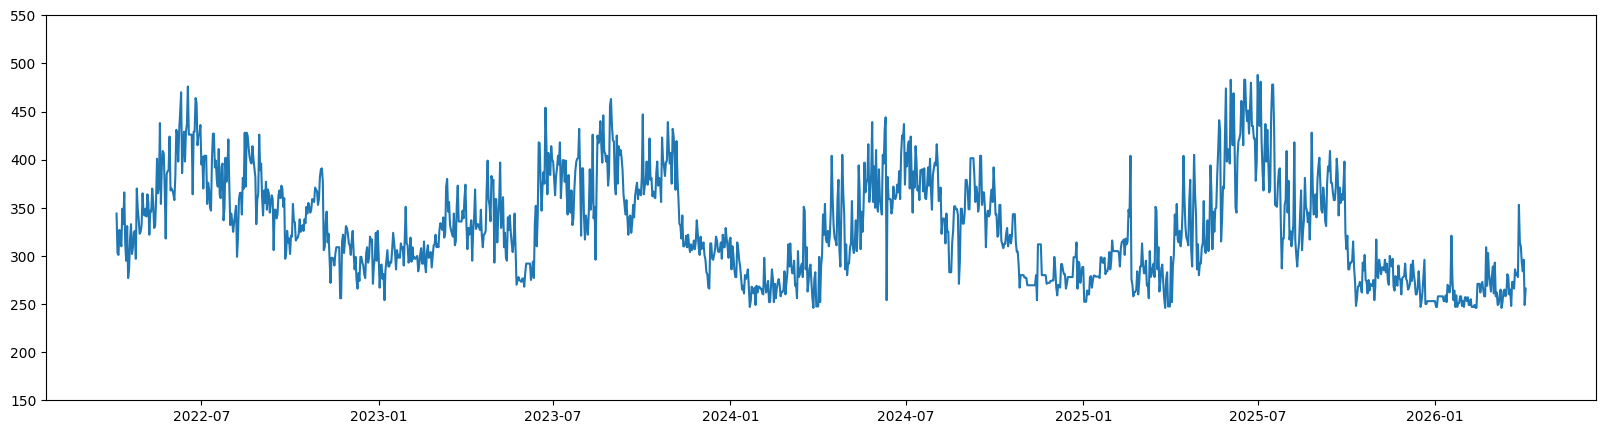

In [5]:
df = pd.read_csv(r'/content/drive/MyDrive/Máster Ciencia de Datos UOC/TFM/desarrollo/qDiarioAnálisis.csv',parse_dates=["StartDateTime"], index_col=["StartDateTime"])
df.index = df.index.date
plt.figure(figsize=(20,5))
plt.plot(df['Consumption'])
plt.ylim([150,550])

In [6]:
# Asegurar que el índice es datetime y está ordenado
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# =========================
# SPLIT 80% (robusto)
# =========================
split_idx = int(len(df) * 0.8)
test_index = df.index[split_idx]

# =========================
# CONJUNTOS
# =========================
test = df.loc[test_index:]

# Predicción naive (lag-1)
predicted = df.shift(1).loc[test_index:].dropna()

# =========================
# OUTPUT
# =========================
print("TEST:")
print(test.head())

print("\nPREDICTED (lag-1):")
print(predicted.head())

TEST:
            Consumption
2025-06-17        483.0
2025-06-18        483.0
2025-06-19        452.0
2025-06-20        440.0
2025-06-21        451.0

PREDICTED (lag-1):
            Consumption
2025-06-17        415.0
2025-06-18        483.0
2025-06-19        483.0
2025-06-20        452.0
2025-06-21        440.0


In [7]:
model_utils.regression_results(model_utils.scale(test), model_utils.scale(predicted))

r2: 0.83
MAE: 0.07
MSE: 0.01
RMSE: 0.1
MAPE (%): 26.99
CC: nan


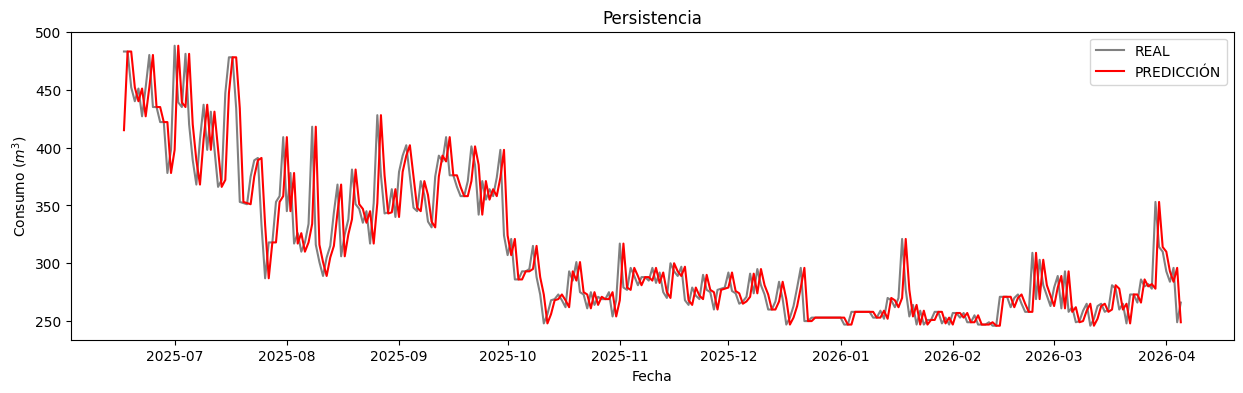

In [8]:
plt.rcParams["figure.figsize"] = (15,4)
plt.title('Persistencia')
plt.plot(test, label='REAL', color='grey')
plt.plot(predicted, label='PREDICCIÓN', color='red')
plt.xlabel("Fecha")
plt.ylabel("Consumo ($m^3$)")
plt.legend()
plt.show()


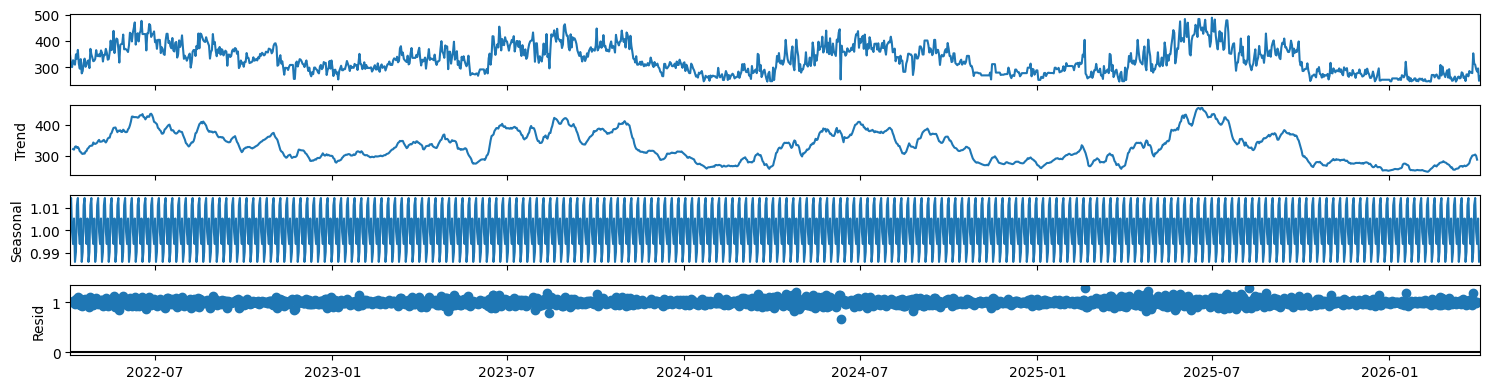

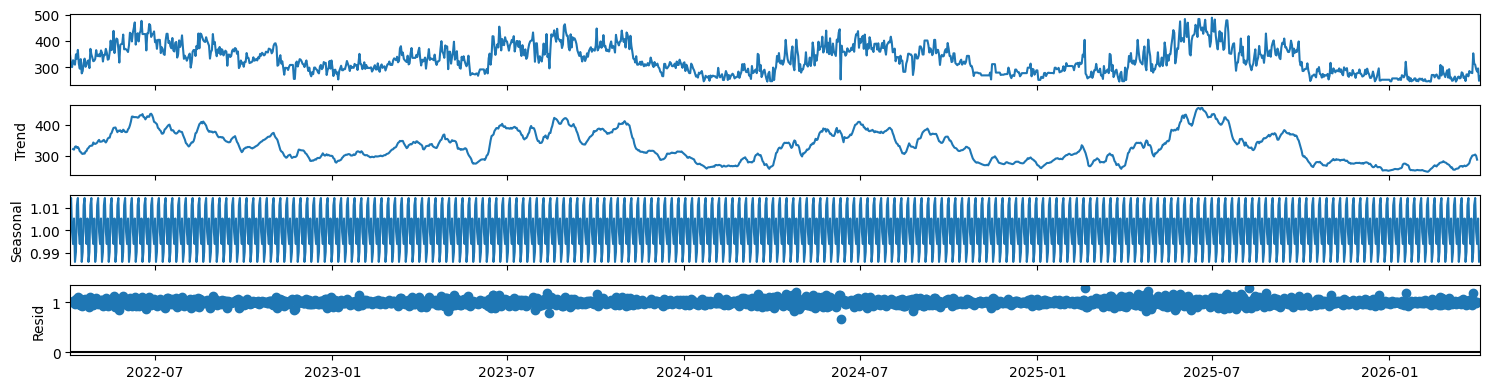

In [9]:
analysis = df[['Consumption']].copy()


decompose_result_mult = seasonal_decompose(analysis.asfreq('D'), model="multiplicative")

trend = decompose_result_mult.trend
seasonal = decompose_result_mult.seasonal
residual = decompose_result_mult.resid

decompose_result_mult.plot()

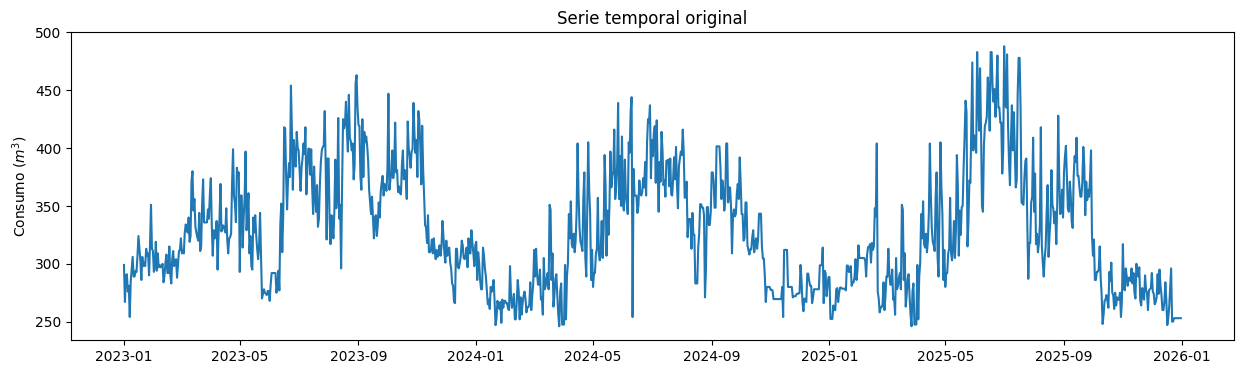

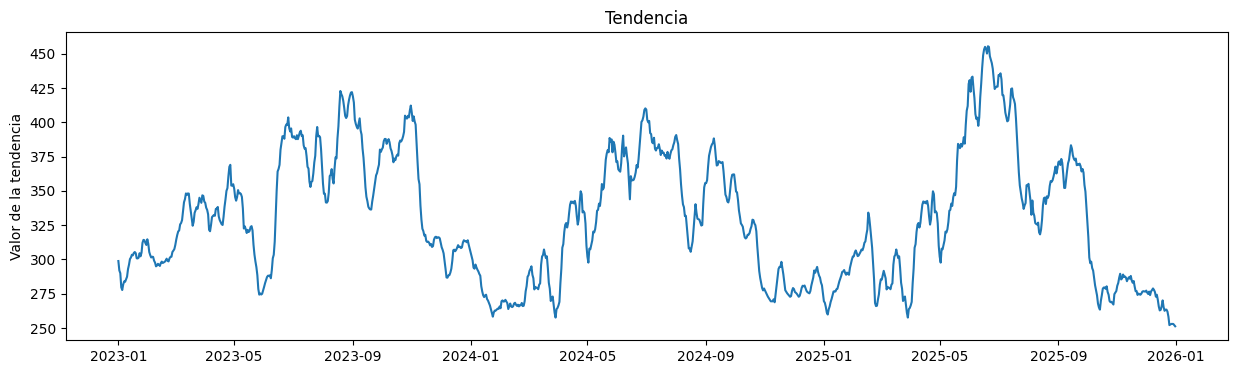

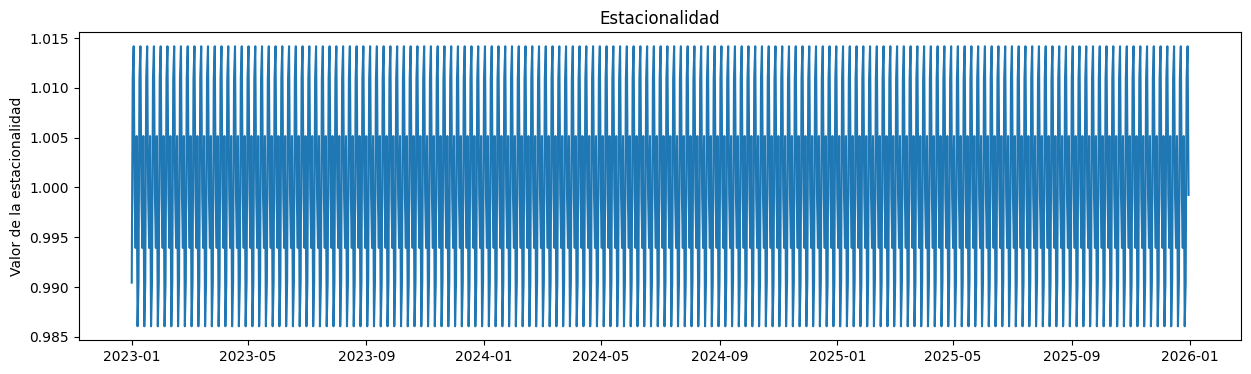

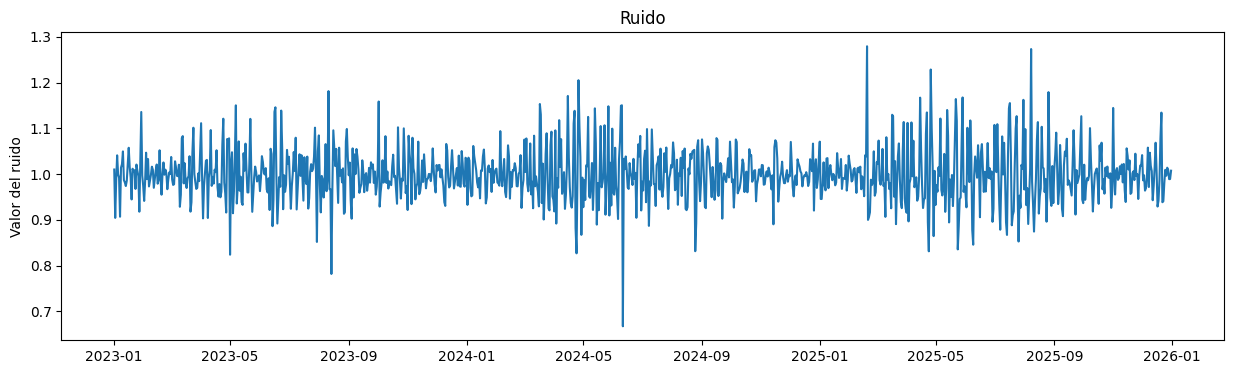

In [10]:
import datetime
plt.figure()
plt.ylabel("Consumo ($m^3$)")
plt.title("Serie temporal original")
plt.plot(df.loc[datetime.date(2023, 1, 1):datetime.date(2025, 12, 31)])
plt.figure()
plt.title("Tendencia")
plt.ylabel("Valor de la tendencia")
plt.plot(trend.loc[datetime.date(2023, 1, 1):datetime.date(2025, 12, 31)])
plt.figure()
plt.ylabel("Valor de la estacionalidad")
plt.title("Estacionalidad")
plt.plot(seasonal.loc[datetime.date(2023, 1, 1):datetime.date(2025, 12, 31)])
plt.figure()
plt.ylabel("Valor del ruido")
plt.title("Ruido")
plt.plot(residual.loc[datetime.date(2023, 1, 1):datetime.date(2025, 12, 31)])

2024-02-01    0.993926
2024-02-02    1.005162
2024-02-03    0.986055
2024-02-04    0.990437
2024-02-05    1.010999
2024-02-06    1.014180
2024-02-07    0.999241
2024-02-08    0.993926
2024-02-09    1.005162
2024-02-10    0.986055
2024-02-11    0.990437
2024-02-12    1.010999
2024-02-13    1.014180
2024-02-14    0.999241
2024-02-15    0.993926
2024-02-16    1.005162
2024-02-17    0.986055
2024-02-18    0.990437
2024-02-19    1.010999
2024-02-20    1.014180
2024-02-21    0.999241
2024-02-22    0.993926
2024-02-23    1.005162
2024-02-24    0.986055
2024-02-25    0.990437
2024-02-26    1.010999
2024-02-27    1.014180
2024-02-28    0.999241
Freq: D, Name: seasonal, dtype: float64


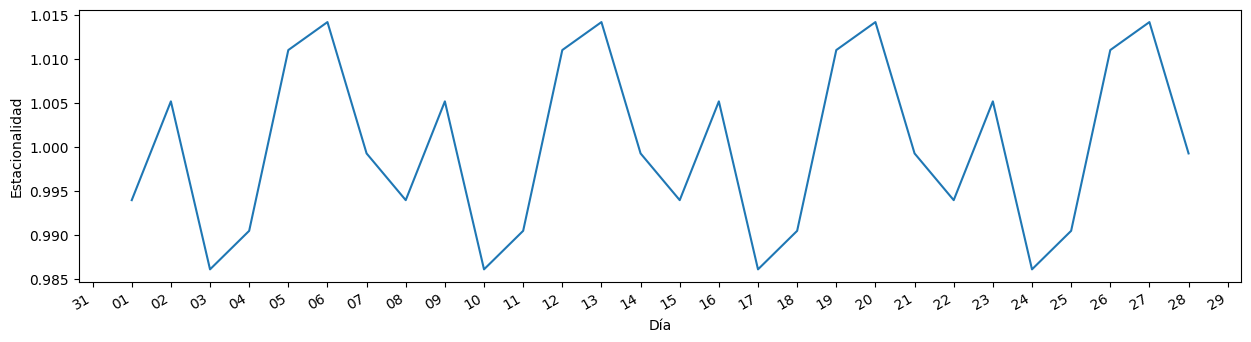

In [11]:
import matplotlib
print(seasonal.loc["2024-02-01":"2024-02-28"])
fig,ax = plt.subplots()
seasonal.loc["2024-02-01":"2024-02-28"].plot(ax=ax, x_compat=True)
plt.xlabel("Día")
plt.ylabel("Estacionalidad")
ax.xaxis.set_major_locator(matplotlib.dates.DayLocator())
ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%d"))

r2: 0.74
MAE: 0.09
MSE: 0.02
RMSE: 0.13
MAPE (%): 35.24
CC: nan


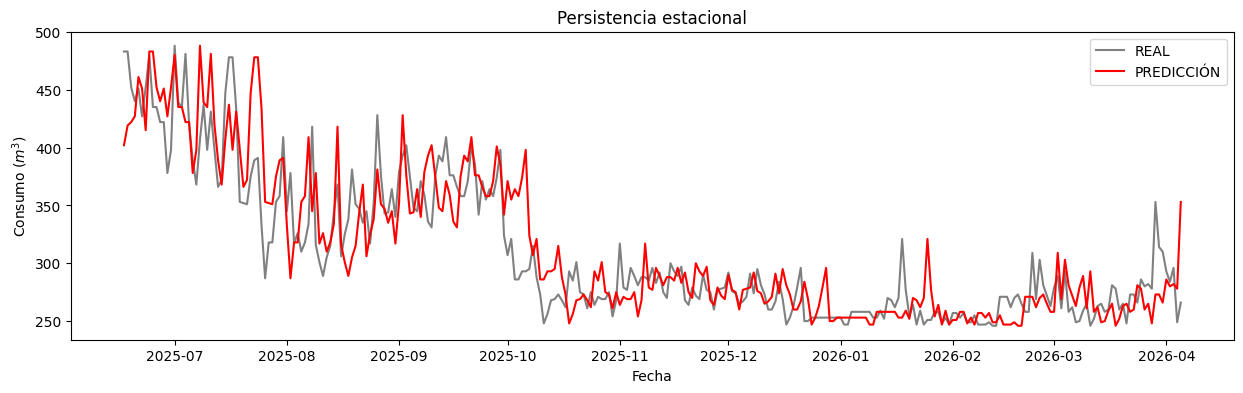

In [12]:
test=df[test_index:]
predicted=df[pd.Timestamp(test_index)- pd.offsets.DateOffset(days=7):].shift(7).dropna()
model_utils.regression_results(model_utils.scale(test),model_utils.scale(predicted))
plt.title('Persistencia estacional')
plt.xlabel("Fecha")
plt.ylabel("Consumo ($m^3$)")
plt.plot(test, label='REAL', color='grey')
plt.plot(predicted, label='PREDICCIÓN', color='red')
plt.legend()
plt.show()

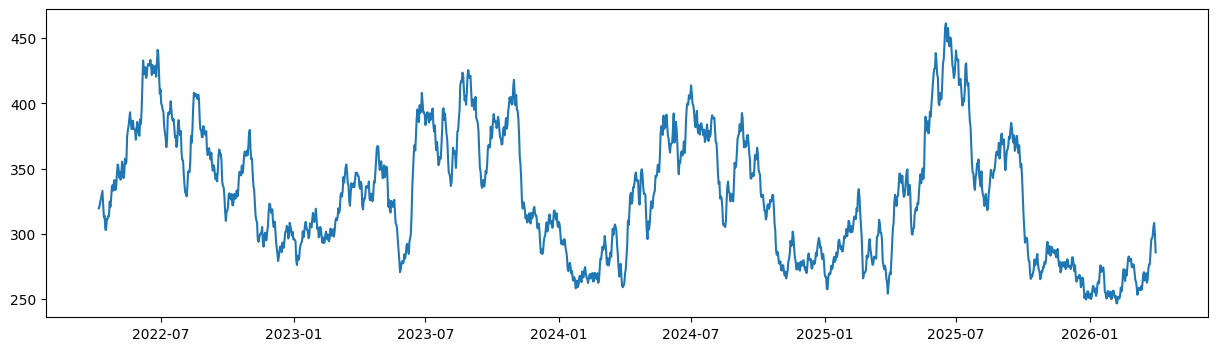

In [13]:
df_sinruido=(trend*seasonal).dropna().to_frame()
df_sinruido.index.name = 'Fecha'
df_sinruido = df_sinruido.set_axis(['Consumption'], axis=1)
plt.plot(df_sinruido)

r2: 0.99
MAE: 0.02
MSE: 0.0
RMSE: 0.03
MAPE (%): 7.61
CC: nan


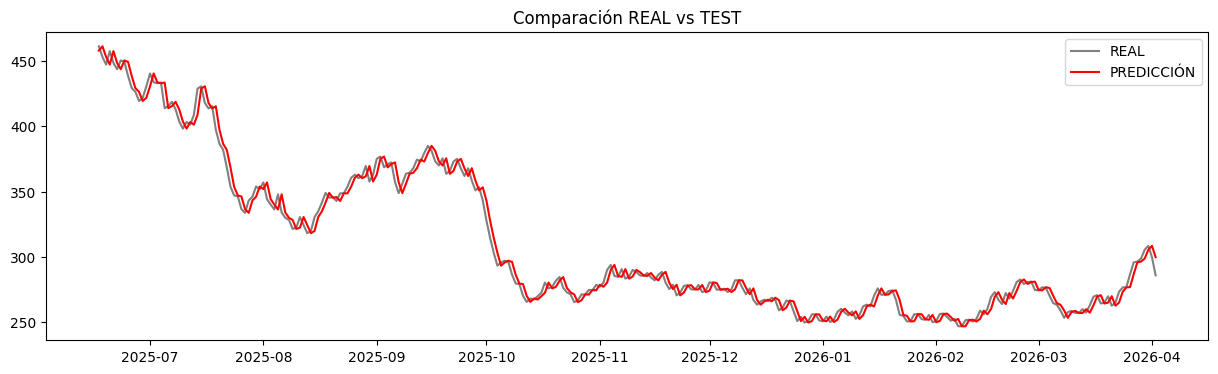

In [14]:
test=df_sinruido[test_index:]
predicted=df_sinruido[pd.Timestamp(test_index)- pd.offsets.DateOffset(days=1):].shift(1).dropna()
model_utils.regression_results(model_utils.scale(test),model_utils.scale(predicted))
plt.title('Comparación REAL vs TEST')
plt.plot(test, label='REAL', color='grey')
plt.plot(predicted, label='PREDICCIÓN', color='red')
plt.legend()
plt.show()

r2: 0.89
MAE: 0.06
MSE: 0.01
RMSE: 0.09
MAPE (%): 21.84
CC: nan


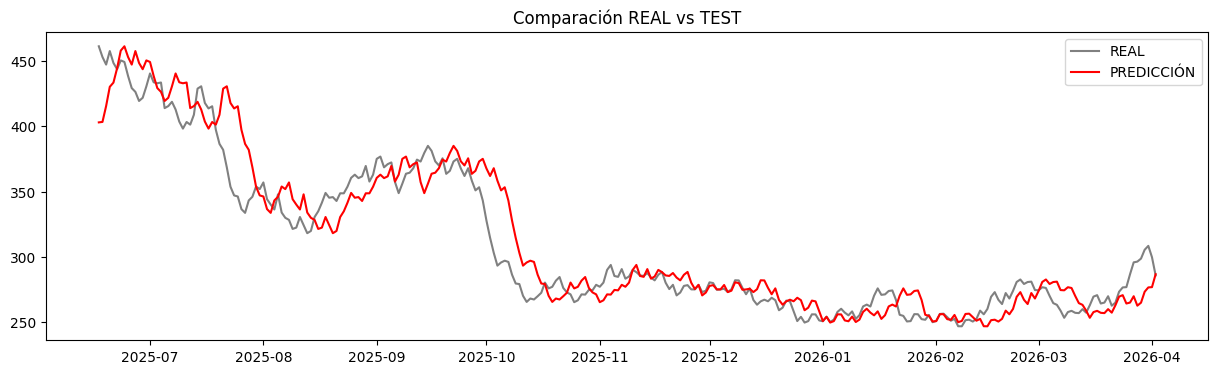

In [15]:
test=df_sinruido[test_index:]
predicted=df_sinruido[pd.Timestamp(test_index)- pd.offsets.DateOffset(days=7):].shift(7).dropna()
model_utils.regression_results(model_utils.scale(test),model_utils.scale(predicted))
plt.title('Comparación REAL vs TEST')
plt.plot(test, label='REAL', color='grey')
plt.plot(predicted, label='PREDICCIÓN', color='red')
plt.legend()
plt.show()